<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Assignment/ESAA_OB_0314_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

# import package
import numpy as np
import os

#5장에서 소개한 moons dataset 불러오기
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X,y = make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

##7.5 부스팅

###7.5.1 에이다부스트

In [2]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth = 1), n_estimators=200,
    algorithm='SAMME', learning_rate=0.5
)
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.95

###7.5.2 그레이디언트 부스팅

에이다부스트는 반복마다 샘플의 가중치를 수정하며 순차적으로 예측기 추가


그레이디언트 부스팅은 이전 예측기가 만든 잔여 오차를 새로운 예측기가 학습


-->최종적으로 모든 모델을 합하여 예측 결과 도출

In [3]:
m = 100
X = 6 * np.random.rand(m, 1)-3
y = 0.5 * X**2 + X + 2 + np.random.rand(m, 1)
X_train, X_test, y_traiin, y_test = train_test_split(X, y, test_size = 0.2)

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X_train, y_train)

y2 = y_train - tree_reg1.predict(X_train)
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X_train, y2)

y3 = y2 - tree_reg2.predict(X_train)
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X_train, y3)

y_pred1 = tree_reg1.predict(X_test)
y_pred2 = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

print(mean_squared_error(y_test, y_pred1), mean_squared_error(y_test, y_pred2)) #엥 성능이 더 안좋은데?

22.601976771096933 23.05072394759919


In [5]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X_train, y_train)

y_pred = gbrt.predict(X_test)
mean_squared_error(y_test, y_pred) #위에서 구현한거랑 같네요

23.05072394759919

In [6]:
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators = 120)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_test, y_pred)
          for y_pred in gbrt.staged_predict(X_test)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=22)

In [7]:
gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True)

min_val_error = float("inf")
error_going_up = 0
for n_estimators in range(1, 120):
  gbrt.n_estimators = n_estimators
  gbrt.fit(X_train, y_train)
  y_pred = gbrt.predict(X_test)
  val_error = mean_squared_error(y_test, y_pred)
  if val_error < min_val_error:
    min_val_error = val_error
    error_going_up = 0
  else:
    error_going_up += 1
    if error_going_up == 5:
      break

In [8]:
import xgboost

xgb_reg = xgboost.XGBRegressor()
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_test)

mean_squared_error(y_test, y_pred)

23.582370806075684

In [9]:
xgb_reg = xgboost.XGBRegressor(early_stopping_rounds = 2)
xgb_reg.fit(X_train, y_train,
            eval_set = [(X_test, y_test)])
y_pred = xgb_reg.predict(X_test)

mean_squared_error(y_test, y_pred)

[0]	validation_0-rmse:4.79702
[1]	validation_0-rmse:4.78217
[2]	validation_0-rmse:4.78094
[3]	validation_0-rmse:4.78007
[4]	validation_0-rmse:4.77970
[5]	validation_0-rmse:4.79544


22.845489359938906

##7.6 스태킹

예측기를 취합할 때 간단한 취합함수를 쓰는 대신, 취합 모델을 사용하는 것


이때의 취합모델: 블렌더 또는 메타학습기라고 부름


멀티레이어 스태킹 앙상블 모델 알고리즘
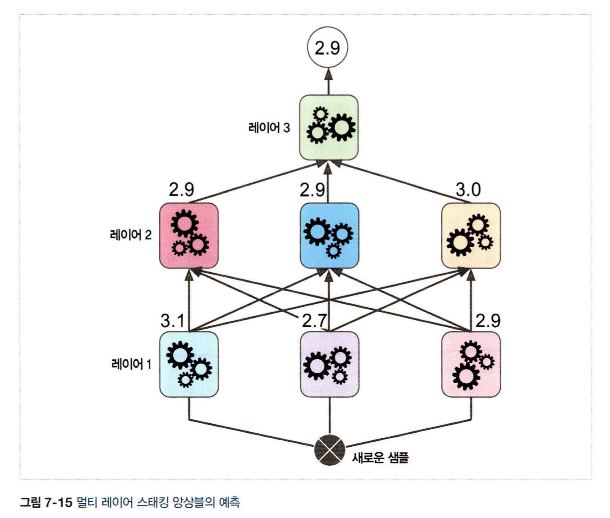

오픈소스 source: DESlib(http://github.com/Menelau/DESlib)

    ----------
    import numpy as np
    from sklearn.linear_model import LogisticRegression
    from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
    
    from deslib.static.base import BaseStaticEnsemble
    
    class StackedClassifier(BaseStaticEnsemble):
    """ A Stacking classifier.

    Parameters
    ----------
    pool_classifiers : list of classifiers (Default = None)
        The generated_pool of classifiers trained for the corresponding
        classification problem. Each base classifiers should support the method
        "predict" and "predict_proba". If None, then the pool of classifiers
        is a bagging classifier.

    meta_classifier : object or None, optional (default=None)
        Classifier model used to aggregate the output of the base classifiers.
        If None, a :class:`LogisticRegression` classifier is used.

    random_state : int, RandomState instance or None, optional (default=None)
        If int, random_state is the seed used by the random number generator;
        If RandomState instance, random_state is the random number generator;
        If None, the random number generator is the RandomState instance used
        by `np.random`.

    passthrough : bool (default=False)
        When False, only the predictions of estimators will be used as
        training data for the meta-classifier. When True, the
        meta-classifier is trained on the predictions as well as the
        original training data.

    n_jobs : int, default=-1
        The number of parallel jobs to run. None means 1 unless in
        a joblib.parallel_backend context. -1 means using all processors.
        Doesn’t affect fit method.

    References
    ----------
    Wolpert, David H. "Stacked generalization." Neural networks 5,
    no. 2 (1992): 241-259.

    Kuncheva, Ludmila I. Combining pattern classifiers: methods and algorithms.
    John Wiley & Sons, 2004.
    """

    def __init__(self, pool_classifiers=None, meta_classifier=None,
                 passthrough=False, random_state=None, n_jobs=-1):

        super(StackedClassifier, self).__init__(
            pool_classifiers=pool_classifiers,
            random_state=random_state,
            n_jobs=n_jobs
        )
        self.meta_classifier = meta_classifier
        self.passthrough = passthrough

    def fit(self, X, y):
        """Fit the model by training a meta-classifier on the outputs of the
        base classifiers

        Parameters
        ----------
        X : array of shape (n_samples, n_features)
            Data used to fit the model.

        y : array of shape (n_samples)
            class labels of each example in X.

        """
        X, y = self._validate_data(
            X,
            y,
            accept_sparse="csr",
            dtype=np.float64,
            order="C",
            accept_large_sparse=False,
        )
        super(StackedClassifier, self).fit(X, y)
        base_preds = self._predict_proba_base(X)
        X_meta = self._connect_input(X, base_preds)

        # Prepare the meta-classifier
        if self.meta_classifier is None:
            self.meta_classifier_ = LogisticRegression(
                solver='lbfgs',
                multi_class='auto',
                max_iter=1000,
                random_state=self.random_state_)

        else:
            self.meta_classifier_ = self.meta_classifier

        self.meta_classifier_.fit(X_meta, self.y_enc_)

        return self

    def predict(self, X):
        """Predict the label of each sample in X and returns the predicted
        label.

        Parameters
        ----------
        X : array of shape (n_samples, n_features)
            The data to be classified

        Returns
        -------
        predicted_labels : array of shape (n_samples)
                           Predicted class for each sample in X.
        """
        check_is_fitted(self, "meta_classifier_")
        X = check_array(X)
        if self.n_features_ != X.shape[1]:
            raise ValueError("Number of features of the model must "
                             "match the input. Model n_features is {0} and "
                             "input n_features is {1}."
                             "".format(self.n_features_, X.shape[1]))

        base_preds = self._predict_proba_base(X)
        X_meta = self._connect_input(X, base_preds)
        preds = self.meta_classifier_.predict(X_meta)
        return self.classes_.take(preds)

    def predict_proba(self, X):
        """Predict the label of each sample in X and returns the predicted
        label.

        Parameters
        ----------
        X : array of shape (n_samples, n_features)
            The data to be classified

        Returns
        -------
        predicted_labels : array of shape (n_samples)
                           Predicted class for each sample in X.
        """
        check_is_fitted(self, "meta_classifier_")
        X = check_array(X)
        if self.n_features_ != X.shape[1]:
            raise ValueError("Number of features of the model must "
                             "match the input. Model n_features is {0} and "
                             "input n_features is {1}."
                             "".format(self.n_features_, X.shape[1]))

        # Check if the meta-classifier can output probabilities
        if not hasattr(self.meta_classifier_, "predict_proba"):
            raise ValueError("Meta-classifier does not implement the"
                             " predict_proba method.")

        base_preds = self._predict_proba_base(X)
        X_meta = self._connect_input(X, base_preds)

        return self.meta_classifier_.predict_proba(X_meta)

    def _connect_input(self, X, base_preds):
        if self.passthrough:
            X_meta = np.hstack((base_preds, X))
        else:
            X_meta = base_preds
        return X_meta

    def _predict_proba_base(self, X):
        """ Get the predictions (probabilities) of each base classifier in the
        pool for all samples in X.

        Parameters
        ----------
        X : array of shape (n_samples, n_features)
            The test examples.

        Returns
        -------
        probabilities : array of shape = [n_samples, n_classifiers x n_classes]
                        Probabilities estimates of each base classifier for all
                        test samples.
        """
        # Check if base classifiers implement the predict proba method.
        self._check_predict_proba()

        probas = np.zeros(
            (X.shape[0], self.n_classifiers_, self.n_classes_))

        for index, clf in enumerate(self.pool_classifiers_):
            probas[:, index] = clf.predict_proba(
                X[:, self.estimator_features_[index]])

        probas = probas.reshape(X.shape[0],
                                self.n_classifiers_ * self.n_classes_)

        # remove first column as both features are collinear.
        if self.n_classes_ == 2:
            probas = probas[:, ::2]

        return probas

    def _check_predict_proba(self):
        """ Checks if each base classifier in the pool implements the
        predict_proba method.

        Raises
        ------
        ValueError
            If the base classifiers do not implements the predict_proba method.
        """
        for clf in self.pool_classifiers_:
            if "predict_proba" not in dir(clf):
                raise ValueError(
                    "All base classifiers should output probability estimates")